In [1]:
!pip install emcee corner

Blazar selezionato: J0021.6-6835
Numero linee osservate usate: 3


100%|██████████| 2000/2000 [02:22<00:00, 14.08it/s] 


Blazar: J0021
Regime: ADAF
Numero walkers = 12
Numero steps   = 2000
Burn-in        = 500
Thin           = 10
Acceptance fraction media = 0.666

log10(m)    = 9.846 [9.694, 9.955]
log10(mdot) = -2.191 [-2.254, -2.092]
m_median    = 7.021e+09 Msun
mdot_median = 6.446e-03


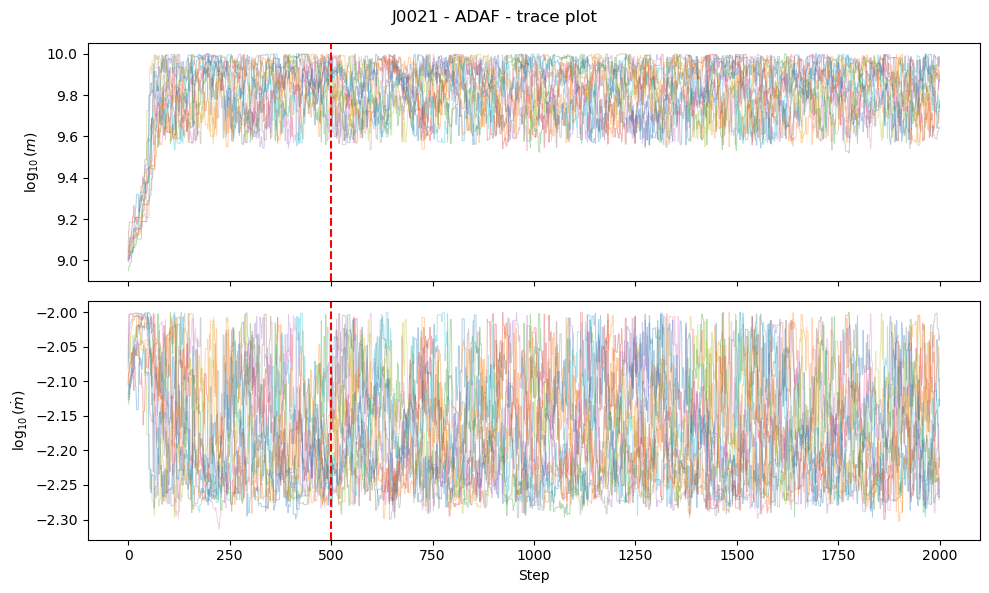

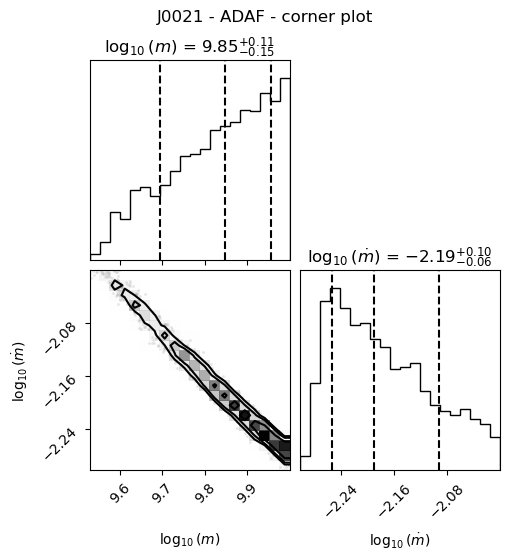

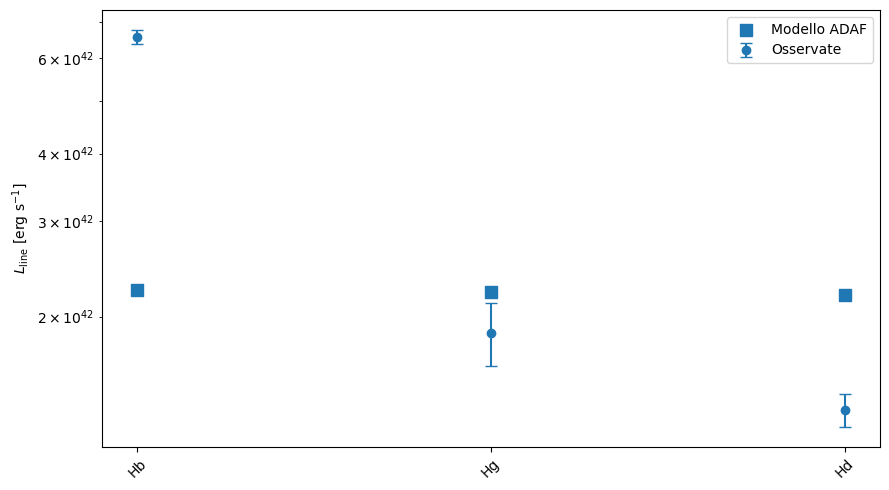

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import kv
import emcee
import corner

# ==========================================================
# COSTANTI FISICHE
# ==========================================================
c = 2.99792458e10
G = 6.67430e-8
h = 6.62607015e-27
kB = 1.380649e-16
sigma = 5.670374419e-5
Msun = 1.98847e33

# ==========================================================
# FILE INPUT
# ==========================================================
file_linee = "Tab_completa_revisione.csv"
file_transizioni = "dati.asc"

# ==========================================================
# PARAMETRI SS / GRIGLIA FREQUENZE
# ==========================================================
eta = 0.083
Nr = 400
Nnu = 120
nu_min = 1e13
nu_max = 1e17

# ==========================================================
# PARAMETRI ADAF
# ==========================================================
ALFA = 0.3
RMIN = 3.0
RMAX = 1000.0
DELTA = 0.0
ADAF_BETA_DEFAULT = 0.5

C1 = 0.5
C3 = 0.3
TNORM = 1.68e-10

# ==========================================================
# PARAMETRI MCMC
# ==========================================================
N_WALKERS = 12
N_STEPS = 800
BURN_IN = 200
THIN = 5

CF_BLR = 0.1
REL_ERR = 0.20

LOGM_MIN, LOGM_MAX = 7.0, 10.0
LOGMDOT_MIN, LOGMDOT_MAX = -5.0, -2.0


# %%
# ==========================================================
# FUNZIONI UTILI
# ==========================================================
def trova_colonna(df, possibili_nomi, obbligatoria=True):
    for nome in possibili_nomi:
        if nome in df.columns:
            return nome
    if obbligatoria:
        raise ValueError(f"Non trovo nessuna di queste colonne: {possibili_nomi}")
    return None


def leggi_transizioni(file_transizioni):
    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=("U50", float, float),
        unpack=True
    )

    return pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list
    })


def estrai_linee_osservate(row, norm_columns):
    risultati = []

    for col in norm_columns:
        valore = row[col]
        if pd.isna(valore) or valore <= 0:
            continue

        line_name = col.replace("_norm", "")
        unc_col = f"{line_name}_norm_unc"

        L_line = valore * 1e42

        if unc_col in row.index and pd.notna(row[unc_col]) and row[unc_col] > 0:
            sigma_L = row[unc_col] * 1e42
        else:
            sigma_L = np.nan

        risultati.append({
            "line_name": line_name,
            "norm_value": valore,
            "L_line_obs": L_line,
            "sigma_L": sigma_L
        })

    return pd.DataFrame(risultati)


# %%
# ==========================================================
# ADAF: FUNZIONI FISICHE
# ==========================================================
def bessk(n, x):
    return kv(n, x)


def g(teta):
    return (
        (1.0 / bessk(2, 1.0 / teta))
        * (2.0 + 2.0 * teta + 1.0 / teta)
        * np.exp(-1.0 / teta)
    )


def temperat(y, mdot, m, beta):
    ff = y[2]**2
    xm = 1e3 * y[1]**2
    teta = y[0]**2

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm

    q1 = 1.2e4 * g(teta) * ALFA**(-2) * C1**(-2) * C3 * beta * m * mdot**2 / RMIN
    q2 = DELTA * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN
    q = q1 + q2

    nup = s1 * s2 * m**(-0.5) * mdot**0.5 * (teta / TNORM)**2 * RMIN**(-5/4)

    psinc = (
        53.0 * (xm / 1000.0)**3 *
        (teta / (1e9 * TNORM))**7 *
        m**0.5 * mdot**1.5
    )

    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    graffa = ((6.2e7 * (teta / (1e9 * TNORM))) / (nup * 1e-12))**(1 - alfac) - 1
    pcomp = (psinc / 0.71) / (1 - alfac) * graffa

    if teta < 1:
        f = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
    else:
        f = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

    pbrems = 4.78 * ALFA**(-2) * C1**(-2) * np.log(RMAX/RMIN) * f * m * mdot**2

    f1 = q - psinc - pcomp - pbrems
    f2 = (1 - ff) * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN - q

    vv = xm**(1/3)
    f3 = (
        vv + 1.852*np.log(vv)
        - 10.36
        - 0.26*np.log(m*mdot)
        + 0.26*np.log(teta**3 * bessk(2, 1/teta))
    )

    return [f1, f3, f2]


def spectrum_adaf(te, f, xm, m, mdot, beta):
    numin = 1e10
    numax = 1e17
    num = 400

    lnu = np.linspace(np.log10(numin), np.log10(numax), num)
    nu = 10**lnu

    teta = 1.68e-10 * te

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm
    s3 = 1.05e-24

    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    lnup = np.log10(s1 * s2 * m**(-0.5) * mdot**0.5 * te**2 * RMIN**(-5/4))
    lnucmax = np.log10(te) + 10.796

    llsinc = (
        3*np.log10(s1*s2)
        + np.log10(s3)
        - (7/4)*np.log10(RMIN)
        + np.log10(m**0.5 * mdot**1.5)
        + 7*np.log10(te)
    )

    lls = np.zeros(num)
    llc = np.zeros(num)
    llb = np.zeros(num)

    for i in range(num):
        if lnu[i] < lnup:
            lls[i] = (
                np.log10(s3)
                + (8/5)*np.log10(s1*s2)
                + np.log10(m**(6/5) * mdot**(4/5))
                + (21/5)*np.log10(te)
                + (2/5)*lnu[i]
            )
        else:
            lls[i] = 0.0

        if lnu[i] > lnup:
            base = llsinc + (alfac - 1)*lnup - alfac*lnu[i]
            cutoff = -(10**(lnu[i] - lnucmax)) / np.log(10)
            llc[i] = base + cutoff
        else:
            llc[i] = 0.0

        if teta < 1:
            fb = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
        else:
            fb = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

        base_b = (
            24.36
            - 2*np.log10(ALFA*C1)
            + np.log10(np.log(RMAX/RMIN) * fb)
            - np.log10(te)
            + np.log10(m * mdot**2)
        )

        cutoff_b = -(4.8e-11 * nu[i] / te) / np.log(10)
        llb[i] = base_b + cutoff_b

    flux = 10**lls + 10**llc + 10**llb
    y = lnu + np.log10(flux)

    return lnu, y


def specdata(m, mdot, beta, verbose=False):
    if verbose:
        print(f"ADAF -> m={m}, mdot={mdot}, beta={beta}")

    y0 = [0.5, 1.0, 0.99]
    sol = root(temperat, y0, args=(mdot, m, beta), tol=1e-10)

    if not sol.success:
        raise RuntimeError(f"Root non converge per m={m:.3e}, mdot={mdot:.3e}")

    y = sol.x

    teta = y[0]**2
    te = teta / 1.68e-10
    xm = 1e3 * y[1]**2
    f = y[2]**2

    lnu, log_nuLnu = spectrum_adaf(te, f, xm, m, mdot, beta)

    nu = 10**lnu
    logLnu = log_nuLnu - lnu
    Lnu = 10**logLnu

    return nu, Lnu, log_nuLnu


# %%
# ==========================================================
# COSTRUZIONE SPETTRO ADAF
# ==========================================================
def costruisci_spettro_adaf(m, mdot, beta=ADAF_BETA_DEFAULT, verbose=False):
    risultato = specdata(
        m=m,
        mdot=mdot,
        beta=beta,
        verbose=verbose
    )

    if isinstance(risultato, tuple):
        if len(risultato) == 3:
            nu = np.asarray(risultato[0], dtype=float)
            Lnu = np.asarray(risultato[1], dtype=float)
            nuLnu = nu * Lnu
        else:
            raise TypeError("Formato tuple di specdata non riconosciuto")
    else:
        raise TypeError("specdata ha restituito un formato non riconosciuto")

    info = {
        "m": m,
        "mdot": mdot,
        "beta": beta
    }

    mask = np.isfinite(nu) & np.isfinite(Lnu) & np.isfinite(nuLnu) & (nu > 0) & (Lnu >= 0)
    nu = nu[mask]
    Lnu = Lnu[mask]
    nuLnu = nuLnu[mask]

    if len(nu) < 2:
        raise RuntimeError("Spettro ADAF non valido dopo filtering")

    idx = np.argsort(nu)
    nu = nu[idx]
    Lnu = Lnu[idx]
    nuLnu = nuLnu[idx]

    return nu, Lnu, nuLnu, info


# %%
# ==========================================================
# CALCOLO L_ION
# ==========================================================
def calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=None):
    risultati = []

    if nu_max is None:
        nu_max = np.max(nu)

    for _, row in df_trans.iterrows():
        line_name = row["line_name"]
        nu_ion = row["nu_ion"]
        E_ion = row["E_ion"]

        if nu_ion >= nu_max:
            L_ion = 0.0
        else:
            mask = (nu >= nu_ion) & (nu <= nu_max)
            if np.sum(mask) < 2:
                L_ion = 0.0
            else:
                L_ion = np.trapezoid(Lnu[mask], nu[mask])

        risultati.append({
            "line_name": line_name,
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "L_ion": L_ion
        })

    return pd.DataFrame(risultati)


# %%
# ==========================================================
# MODELLO DI RIGA ADAF
# ==========================================================
def predici_linee_da_modello_adaf(logm, logmdot, df_trans, cf_blr=0.1, beta_adaf=0.5):
    m = 10**logm
    mdot = 10**logmdot

    nu, Lnu, nuLnu, info = costruisci_spettro_adaf(
        m=m,
        mdot=mdot,
        beta=beta_adaf,
        verbose=False
    )

    df_lion = calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=1e17)
    df_lion["L_line_mod"] = cf_blr * df_lion["L_ion"]

    return df_lion


# %%
# ==========================================================
# PREPARAZIONE DATI OSSERVATI PER UN BLAZAR
# ==========================================================
def prepara_dati_blazar(label_target, file_linee, file_transizioni):
    df_tab = pd.read_csv(file_linee)
    df_trans = leggi_transizioni(file_transizioni)

    col_name_tab = trova_colonna(df_tab, ["label", "file_name", "name", "nome", "blazar"])
    norm_columns = [col for col in df_tab.columns if col.endswith("_norm")]

    df_all = df_tab.rename(columns={col_name_tab: "label"}).copy()
    df_all["label"] = df_all["label"].astype(str).str.strip()

    label_target_clean = str(label_target).strip()

    df_match = df_all[df_all["label"] == label_target_clean].copy()

    if df_match.empty:
        df_match = df_all[
            df_all["label"].str.contains(label_target_clean, case=False, na=False)
        ].copy()

    if df_match.empty:
        print("Label disponibili:")
        print(df_all["label"].drop_duplicates().sort_values().tolist())
        raise ValueError(f"Nessun blazar trovato per label_target = '{label_target}'")

    if len(df_match) > 1:
        print("Trovati più blazar compatibili:")
        print(df_match["label"].tolist())
        print("Uso il primo della lista.")

    row = df_match.iloc[0]

    df_obs = estrai_linee_osservate(row, norm_columns)

    df_obs = df_obs.merge(
        df_trans[["line_name", "E_ion", "nu_ion"]],
        on="line_name",
        how="left"
    )

    df_obs["sigma_L"] = pd.to_numeric(df_obs["sigma_L"], errors="coerce")
    df_obs.loc[
        df_obs["sigma_L"].isna() | (df_obs["sigma_L"] <= 0),
        "sigma_L"
    ] = REL_ERR * df_obs["L_line_obs"]

    print(f"Blazar selezionato: {row['label']}")
    print(f"Numero linee osservate usate: {len(df_obs)}")

    return df_all, df_trans, df_obs


# %%
# ==========================================================
# PRIOR ADAF
# ==========================================================
def log_prior_adaf(theta):
    logm, logmdot = theta

    if not (7.0 < logm < 10.0):
        return -np.inf

    if not (-5.0 < logmdot < -2.0):
        return -np.inf

    return 0.0


# %%
# ==========================================================
# LIKELIHOOD ADAF
# ==========================================================
def log_likelihood_adaf(theta, df_obs, df_trans, cf_blr=0.1, beta_adaf=0.5):
    logm, logmdot = theta

    try:
        linee_necessarie = df_obs["line_name"].unique().tolist()
        df_trans_use = df_trans[df_trans["line_name"].isin(linee_necessarie)].copy()

        df_mod = predici_linee_da_modello_adaf(
            logm=logm,
            logmdot=logmdot,
            df_trans=df_trans_use,
            cf_blr=cf_blr,
            beta_adaf=beta_adaf
        )
    except Exception:
        return -np.inf

    df_cmp = df_obs.merge(
        df_mod[["line_name", "L_line_mod"]],
        on="line_name",
        how="inner"
    )

    df_cmp = df_cmp[
        df_cmp["L_line_obs"].notna() &
        df_cmp["sigma_L"].notna() &
        df_cmp["L_line_mod"].notna() &
        np.isfinite(df_cmp["L_line_mod"]) &
        (df_cmp["L_line_mod"] >= 0) &
        (df_cmp["sigma_L"] > 0)
    ].copy()

    if len(df_cmp) == 0:
        return -np.inf

    resid = df_cmp["L_line_obs"].values - df_cmp["L_line_mod"].values
    sigma = df_cmp["sigma_L"].values

    if not np.all(np.isfinite(resid)) or not np.all(np.isfinite(sigma)):
        return -np.inf

    return -0.5 * np.sum((resid / sigma)**2 + np.log(2*np.pi*sigma**2))


# %%
# ==========================================================
# POSTERIOR ADAF
# ==========================================================
def log_posterior_adaf(theta, df_obs, df_trans, cf_blr=0.1, beta_adaf=0.5):
    lp = log_prior_adaf(theta)
    if not np.isfinite(lp):
        return -np.inf

    ll = log_likelihood_adaf(
        theta=theta,
        df_obs=df_obs,
        df_trans=df_trans,
        cf_blr=cf_blr,
        beta_adaf=beta_adaf
    )

    if not np.isfinite(ll):
        return -np.inf

    return lp + ll


# %%
# ==========================================================
# INIZIALIZZAZIONE WALKERS
# ==========================================================
def inizializza_walkers_adaf(
    nwalkers,
    guess_logm=9.0,
    guess_logmdot=np.log10(8e-3),
    spread_logm=0.03,
    spread_logmdot=0.03,
    random_seed=42
):
    rng = np.random.default_rng(random_seed)

    pos = []
    while len(pos) < nwalkers:
        trial = np.array([
            rng.normal(guess_logm, spread_logm),
            rng.normal(guess_logmdot, spread_logmdot)
        ])

        if np.isfinite(log_prior_adaf(trial)):
            pos.append(trial)

    return np.array(pos)


# %%
# ==========================================================
# RUN EMCEE ADAF
# ==========================================================
def run_emcee_adaf(
    df_obs,
    df_trans,
    nwalkers=12,
    nsteps=800,
    initial_guess=(9.0, np.log10(8e-3)),
    cf_blr=0.1,
    beta_adaf=0.5,
    random_seed=42
):
    ndim = 2

    initial_pos = inizializza_walkers_adaf(
        nwalkers=nwalkers,
        guess_logm=initial_guess[0],
        guess_logmdot=initial_guess[1],
        spread_logm=0.03,
        spread_logmdot=0.03,
        random_seed=random_seed
    )

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_posterior_adaf,
        args=(df_obs, df_trans, cf_blr, beta_adaf)
    )

    sampler.run_mcmc(initial_pos, nsteps, progress=True)

    return sampler


# %%
# ==========================================================
# RIASSUNTO POSTERIORE
# ==========================================================
def riassumi_posteriore(samples):
    logm = samples[:, 0]
    logmdot = samples[:, 1]

    out = {
        "logm_median": np.median(logm),
        "logm_p16": np.percentile(logm, 16),
        "logm_p84": np.percentile(logm, 84),
        "logmdot_median": np.median(logmdot),
        "logmdot_p16": np.percentile(logmdot, 16),
        "logmdot_p84": np.percentile(logmdot, 84),
    }

    out["m_median"] = 10**out["logm_median"]
    out["mdot_median"] = 10**out["logmdot_median"]

    return out


# %%
# ==========================================================
# TRACE PLOT
# ==========================================================
def plot_trace_emcee(sampler, burn_in=0, titolo=""):
    chain = sampler.get_chain()
    nsteps, nwalkers, ndim = chain.shape

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    for i in range(nwalkers):
        axes[0].plot(chain[:, i, 0], alpha=0.35, lw=0.7)
        axes[1].plot(chain[:, i, 1], alpha=0.35, lw=0.7)

    axes[0].axvline(burn_in, color="red", linestyle="--")
    axes[1].axvline(burn_in, color="red", linestyle="--")

    axes[0].set_ylabel(r"$\log_{10}(m)$")
    axes[1].set_ylabel(r"$\log_{10}(\dot m)$")
    axes[1].set_xlabel("Step")

    fig.suptitle(titolo)
    plt.tight_layout()
    plt.show()


# %%
# ==========================================================
# CORNER PLOT
# ==========================================================
def plot_corner_emcee(samples, titolo=""):
    fig = corner.corner(
        samples,
        labels=[r"$\log_{10}(m)$", r"$\log_{10}(\dot m)$"],
        quantiles=[0.16, 0.50, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12}
    )
    fig.suptitle(titolo, y=1.02)
    plt.show()


# %%
# ==========================================================
# CONFRONTO LINEE OSSERVATE VS MODELLO BEST-FIT
# ==========================================================
def plot_best_fit_linee_adaf(df_obs, df_trans, best_logm, best_logmdot, cf_blr=0.1, beta_adaf=0.5):
    df_mod = predici_linee_da_modello_adaf(
        logm=best_logm,
        logmdot=best_logmdot,
        df_trans=df_trans,
        cf_blr=cf_blr,
        beta_adaf=beta_adaf
    )

    df_cmp = df_obs.merge(
        df_mod[["line_name", "L_line_mod"]],
        on="line_name",
        how="inner"
    )

    if df_cmp.empty:
        print("Nessuna linea comune tra osservazioni e modello.")
        return

    x = np.arange(len(df_cmp))

    plt.figure(figsize=(9, 5))
    plt.errorbar(
        x,
        df_cmp["L_line_obs"],
        yerr=df_cmp["sigma_L"],
        fmt="o",
        capsize=4,
        label="Osservate"
    )
    plt.scatter(x, df_cmp["L_line_mod"], marker="s", s=70, label="Modello ADAF")

    plt.yscale("log")
    plt.xticks(x, df_cmp["line_name"], rotation=45)
    plt.ylabel(r"$L_{\rm line}$ [erg s$^{-1}$]")
    plt.legend()
    plt.tight_layout()
    plt.show()


# %%
# ==========================================================
# FIT COMPLETO ADAF
# ==========================================================
def fit_blazar_mcmc_adaf(
    label_target,
    initial_guess=(9.0, np.log10(8e-3)),
    nwalkers=12,
    nsteps=800,
    burn_in=200,
    thin=5,
    cf_blr=0.1,
    beta_adaf=0.5,
    random_seed=42
):
    df_all, df_trans, df_obs = prepara_dati_blazar(
        label_target=label_target,
        file_linee=file_linee,
        file_transizioni=file_transizioni
    )

    sampler = run_emcee_adaf(
        df_obs=df_obs,
        df_trans=df_trans,
        nwalkers=nwalkers,
        nsteps=nsteps,
        initial_guess=initial_guess,
        cf_blr=cf_blr,
        beta_adaf=beta_adaf,
        random_seed=random_seed
    )

    chain = sampler.get_chain()
    log_prob = sampler.get_log_prob()
    flat_samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)

    summary = riassumi_posteriore(flat_samples)
    acc_frac = np.mean(sampler.acceptance_fraction)

    print("=" * 80)
    print(f"Blazar: {label_target}")
    print("Regime: ADAF")
    print(f"Numero walkers = {nwalkers}")
    print(f"Numero steps   = {nsteps}")
    print(f"Burn-in        = {burn_in}")
    print(f"Thin           = {thin}")
    print(f"Acceptance fraction media = {acc_frac:.3f}")
    print()
    print(f"log10(m)    = {summary['logm_median']:.3f} "
          f"[{summary['logm_p16']:.3f}, {summary['logm_p84']:.3f}]")
    print(f"log10(mdot) = {summary['logmdot_median']:.3f} "
          f"[{summary['logmdot_p16']:.3f}, {summary['logmdot_p84']:.3f}]")
    print(f"m_median    = {summary['m_median']:.3e} Msun")
    print(f"mdot_median = {summary['mdot_median']:.3e}")
    print("=" * 80)

    plot_trace_emcee(
        sampler,
        burn_in=burn_in,
        titolo=f"{label_target} - ADAF - trace plot"
    )

    plot_corner_emcee(
        flat_samples,
        titolo=f"{label_target} - ADAF - corner plot"
    )

    plot_best_fit_linee_adaf(
        df_obs=df_obs,
        df_trans=df_trans,
        best_logm=summary["logm_median"],
        best_logmdot=summary["logmdot_median"],
        cf_blr=cf_blr,
        beta_adaf=beta_adaf
    )

    return {
        "df_obs": df_obs,
        "df_trans": df_trans,
        "sampler": sampler,
        "chain": chain,
        "log_prob": log_prob,
        "flat_samples": flat_samples,
        "summary": summary,
        "acceptance_fraction_mean": acc_frac
    }


# %%
# ==========================================================
# RUN FINALE
# ==========================================================
ris_adaf = fit_blazar_mcmc_adaf(
    label_target="J0021",
    initial_guess=(9.0, np.log10(8e-3)),
    nwalkers=12,
    nsteps=2000,
    burn_in=500,
    thin=10,
    cf_blr=0.1,
    beta_adaf=0.5,
    random_seed=42
)